In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate2d
from scipy.ndimage import maximum_filter
from typing import List, Tuple, Dict


In [4]:
OUTDIR = "./lr4_outputs"
os.makedirs(OUTDIR, exist_ok=True)


IMG_SIZE = 64
OBJ_BRIGHTNESS = 128.0
VAR_LIST = [3000, 5000]   # дисперсии фона
TEMPLATE_SIZE = (3, 3)
FOOTPRINT = 3             # окно для локального макс. при детекции
THRESHOLD_DEFAULT = 0.5   # фиксированный порог (можно менять)
DETECTION_TOL = 1         # расстояние (Chebyshev) для соответствия найденных и истинных центров

# центры объектов (уверенно на изображении 64x64)
CENTERS_4T = [(16,16), (16,48), (48,16), (48,48)]
# для случая 2T + 2T_inv: первые 2 -> T, последние 2 -> T_inv
CENTERS_2T_2TINV = CENTERS_4T.copy()

# -------------- Шаблоны --------------
T = np.array([[1,1,1],
              [0,1,0],
              [0,1,0]], dtype=float)
T_INV = np.flipud(T)
TEMPLATES = {"T": T, "T_inv": T_INV}
T_INV

array([[0., 1., 0.],
       [0., 1., 0.],
       [1., 1., 1.]])

# Вспомогательные функции

In [5]:
def place_objects(base: np.ndarray, centers: List[Tuple[int,int]], template: np.ndarray, brightness=OBJ_BRIGHTNESS) -> np.ndarray:
    """Добавляет шаблон в заданные центры (усиление brightness)."""
    img = base.copy()
    th, tw = template.shape
    ch = th // 2
    cw = tw // 2
    for (r,c) in centers:
        r0 = r - ch; c0 = c - cw
        if r0 < 0 or c0 < 0 or (r0+th) > img.shape[0] or (c0+tw) > img.shape[1]:
            continue
        img[r0:r0+th, c0:c0+tw] += brightness * template
    return img

In [6]:
def normalized_cross_correlation(image: np.ndarray, template: np.ndarray) -> np.ndarray:
    """
    Вычисляет поле нормализованной взаимной корреляции (NCC).
    Версия: используется корреляция с шаблоном, вычитанием локального среднего в числителе
    и нормировкой по локальной энергии в окне шаблона.
    Возвращает массив той же формы, что image (mode='same').
    """
    # шаблон центровка
    t = template - np.mean(template)
    t_energy = np.sum(t*t)
    # числитель: коррелируем (I - local_mean) с t. Для эффективности сначала корреляция I*t,
    # затем корректируем с учётом шаблонного среднего веса — но для простоты используем подход:
    # num = correlate2d(image, t, mode='same', boundary='fill', fillvalue=0) - mean(image)*sum(t)
    # Вместо глобального mean используем локальную (см. ниже).
    # Полный корректный NCC: num = correlate2d(I, t, 'same') - local_mean * sum(t)
    # Чтобы получить local_mean, используем свёртку с ядром ones.
    kernel = np.ones(template.shape)
    sum_I = correlate2d(image, kernel, mode='same', boundary='fill', fillvalue=0)          # сумма в окне
    sum_I2 = correlate2d(image*image, kernel, mode='same', boundary='fill', fillvalue=0)   # сумма квадратов в окне
    local_mean = sum_I / (template.size)
    # correlate image with zero-mean template
    num = correlate2d(image, t, mode='same', boundary='fill', fillvalue=0) - local_mean * np.sum(t)
    # локальная дисперсия * N (формула: sum(x^2) - (sum(x)^2)/N)
    local_var_timesN = sum_I2 - (sum_I * local_mean)
    # возможны небольшие отрицания из-за численных ошибок -> ограничим
    local_var_timesN = np.maximum(local_var_timesN, 0.0)
    denom = np.sqrt(local_var_timesN * t_energy)
    # чтобы не делить на ноль
    denom = np.where(denom <= 1e-9, 1e-9, denom)
    ncc = num / denom
    return ncc

In [7]:
def detect_peaks(ncc: np.ndarray, threshold: float=THRESHOLD_DEFAULT, footprint: int=FOOTPRINT) -> List[Tuple[int,int]]:
    """Находит локальные максимумы NCC, которые > threshold. Возвращает список координат (r,c)."""
    neighborhood = maximum_filter(ncc, size=footprint, mode='reflect')
    peaks_mask = (ncc == neighborhood) & (ncc > threshold)
    coords = np.argwhere(peaks_mask)
    return [tuple(p) for p in coords]

In [8]:
def evaluate_detections(detected: List[Tuple[int,int]], true_centers: List[Tuple[int,int]], tol: int=DETECTION_TOL):
    """Сопоставляет детекции с истинными центрами. Возвращает (false_positives, missed, matched)."""
    matched_idx = set()
    false_positives = 0
    for d in detected:
        found = False
        for i, t in enumerate(true_centers):
            if i in matched_idx: 
                continue
            if max(abs(d[0]-t[0]), abs(d[1]-t[1])) <= tol:
                matched_idx.add(i)
                found = True
                break
        if not found:
            false_positives += 1
    missed = len(true_centers) - len(matched_idx)
    return false_positives, missed, len(matched_idx)


In [9]:
def plot_image(img: np.ndarray, title: str = "", cmap='gray', vmin=None, vmax=None, savepath: str = None):
    plt.figure(figsize=(4.5,4.5))
    plt.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.axis('off')
    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=150)
    plt.show()

In [10]:
def plot_two(ncc: np.ndarray, mask: np.ndarray, title: str="", savepath: str=None):
    plt.figure(figsize=(8,4.5))
    plt.suptitle(title)
    plt.subplot(1,2,1)
    plt.title("NCC field")
    plt.imshow(ncc, cmap='gray')
    plt.colorbar()
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.title("Detected peaks (mask)")
    plt.imshow(mask, cmap='gray')
    plt.axis('off')
    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=150)
    plt.show()

In [11]:
# -------------- Основной процесс --------------
def run_experiment():
    results = {}  # results[var][image_name] = {...}
    for var in VAR_LIST:
        sigma = np.sqrt(var)
        # создаём базовый фон
        background = np.random.normal(loc=0.0, scale=sigma, size=(IMG_SIZE, IMG_SIZE))
        # 3 исходных изображения
        img_background_only = background.copy()
        img_4T = place_objects(background, CENTERS_4T, T)
        # создаём смешанный (2T + 2T_inv)
        img_2T_2Tinv = place_objects(background, CENTERS_2T_2TINV[:2], T)
        img_2T_2Tinv = place_objects(img_2T_2Tinv, CENTERS_2T_2TINV[2:], T_INV)

        images = {
            "background_only": img_background_only,
            "objects_T_4": img_4T,
            "objects_T_and_Tinv_2plus2": img_2T_2Tinv
        }

        res_by_image = {}
        for name, img in images.items():
            ncc_fields = {}
            detections = {}
            evals = {}
            # вычисляем NCC для каждого шаблона
            for key, templ in TEMPLATES.items():
                ncc = normalized_cross_correlation(img, templ)
                ncc_fields[key] = ncc
                dets = detect_peaks(ncc, threshold=THRESHOLD_DEFAULT, footprint=FOOTPRINT)
                detections[key] = dets

            # Оценка: разные ground-truth для разных изображений
            if name == "background_only":
                for key in TEMPLATES.keys():
                    fp, missed, matched = evaluate_detections(detections[key], [])
                    evals[key] = {"false_positives": fp, "missed": missed, "matched": matched}
            elif name == "objects_T_4":
                for key in TEMPLATES.keys():
                    fp, missed, matched = evaluate_detections(detections[key], CENTERS_4T)
                    evals[key] = {"false_positives": fp, "missed": missed, "matched": matched}
            else:  # mixed
                # для T: первые два центра; для T_inv: последние два
                evals_temp = {}
                for key in TEMPLATES.keys():
                    if key == "T":
                        gt = CENTERS_2T_2TINV[:2]
                    else:
                        gt = CENTERS_2T_2TINV[2:]
                    fp, missed, matched = evaluate_detections(detections[key], gt)
                    evals_temp[key] = {"false_positives": fp, "missed": missed, "matched": matched}
                evals = evals_temp

            # сохраняем
            res_by_image[name] = {
                "image": img,
                "ncc": ncc_fields,
                "detections": detections,
                "eval": evals
            }

            # Визуализация и сохранение изображений/полей
            img_fname = os.path.join(OUTDIR, f"img_{name}_var{var}.png")
            plot_image(img, title=f"{name} (var={var})", savepath=img_fname)
            np.save(os.path.join(OUTDIR, f"img_{name}_var{var}.npy"), img)

            for key in ncc_fields.keys():
                ncc = ncc_fields[key]
                dets = detections[key]
                mask = np.zeros_like(ncc)
                for (r,c) in dets:
                    mask[r,c] = 1.0
                plot_two(ncc, mask, title=f"NCC with template '{key}' — {name} — var {var}",
                         savepath=os.path.join(OUTDIR, f"ncc_{name}_{key}_var{var}.png"))
                np.save(os.path.join(OUTDIR, f"ncc_{name}_{key}_var{var}.npy"), ncc)

            # гистограмма NCC (объединённо по шаблонам)
            all_ncc = np.concatenate([ncc_fields[k].ravel() for k in ncc_fields.keys()])
            plt.figure(figsize=(6,3))
            plt.hist(all_ncc, bins=100)
            plt.title(f"Histogram of NCC — {name} — var {var}")
            plt.savefig(os.path.join(OUTDIR, f"hist_ncc_{name}_var{var}.png"), bbox_inches='tight', dpi=150)
            plt.show()

        results[var] = res_by_image

    # компактная печать результатов
    for var, data in results.items():
        print(f"\n=== Summary for variance = {var} ===")
        for name, info in data.items():
            print(f" Image: {name}")
            for key, ev in info["eval"].items():
                print(f"  Template {key}: matched={ev['matched']}, missed={ev['missed']}, false_pos={ev['false_positives']}")
    print(f"\nAll outputs saved to '{OUTDIR}' (png + .npy).")

    # возвращаем структуру для возможной дальнейшей обработки
    return results

In [12]:
# -------------- Доп. функция: подбор порога перебором --------------
def threshold_sweep_for_image(img: np.ndarray, templ: np.ndarray, thresholds: List[float], true_centers: List[Tuple[int,int]]):
    """Перебирает пороги и возвращает (threshold -> (FP, missed, matched))."""
    ncc = normalized_cross_correlation(img, templ)
    summary = {}
    for thr in thresholds:
        dets = detect_peaks(ncc, threshold=thr, footprint=FOOTPRINT)
        fp, missed, matched = evaluate_detections(dets, true_centers)
        summary[thr] = {"fp": fp, "missed": missed, "matched": matched, "num_dets": len(dets)}
    return ncc, summary

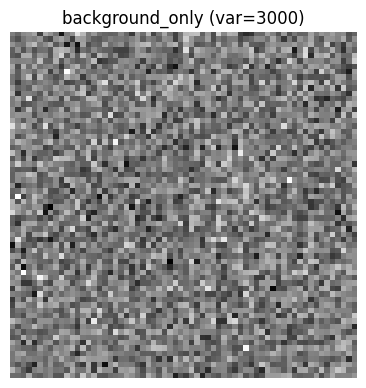

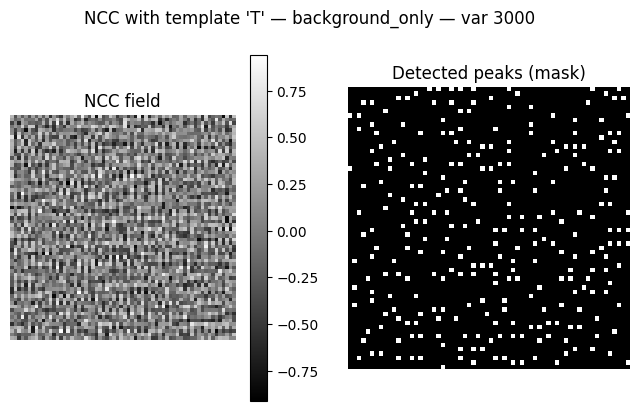

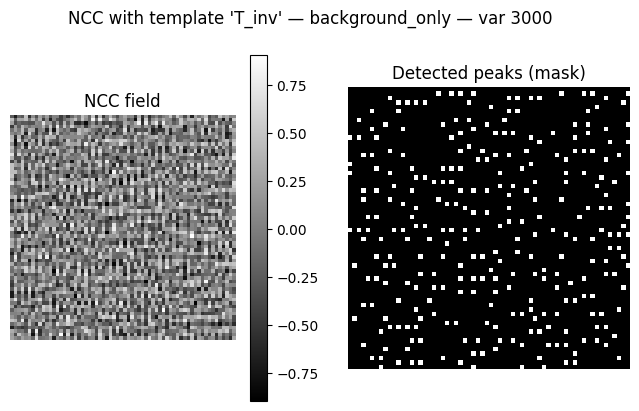

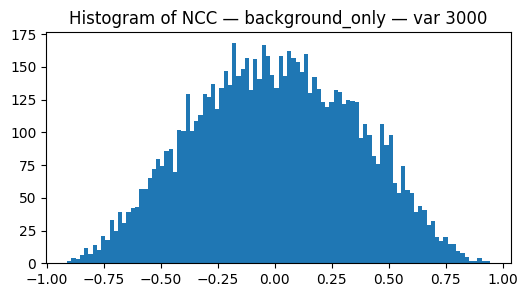

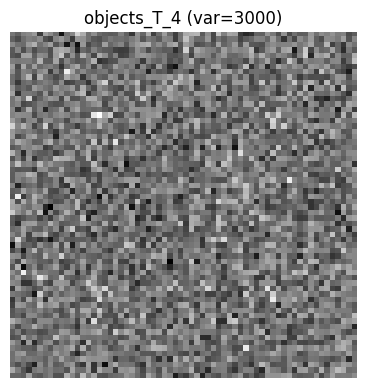

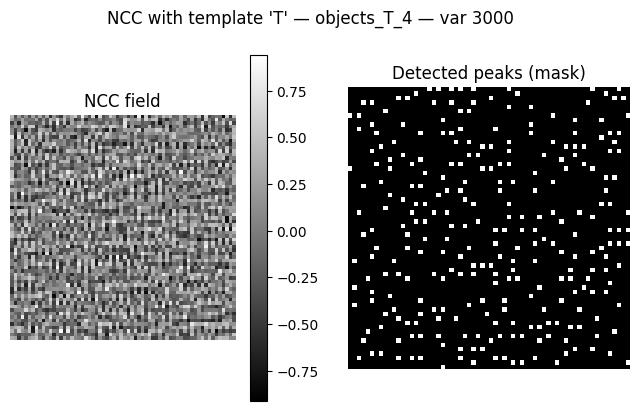

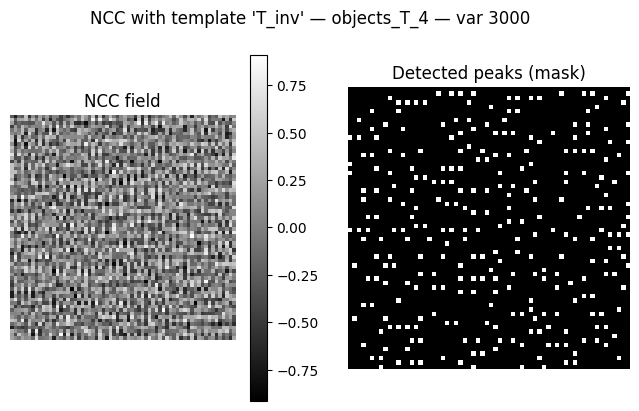

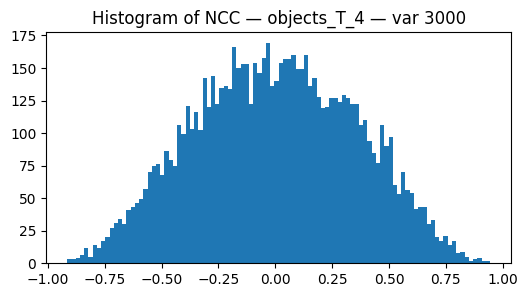

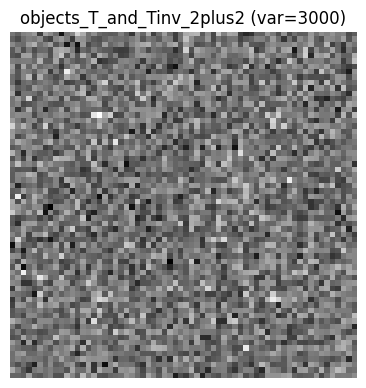

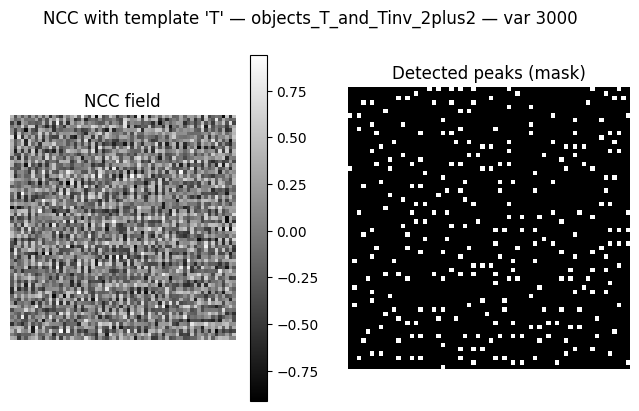

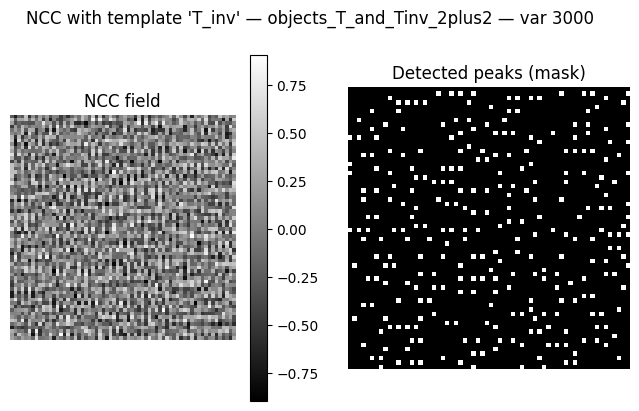

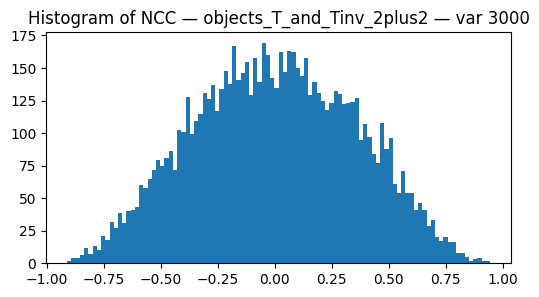

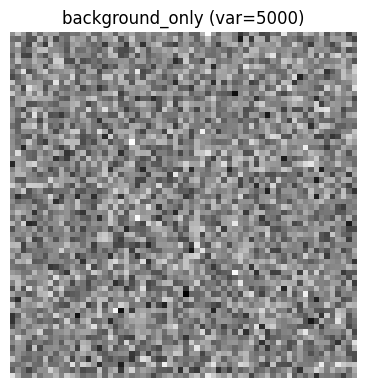

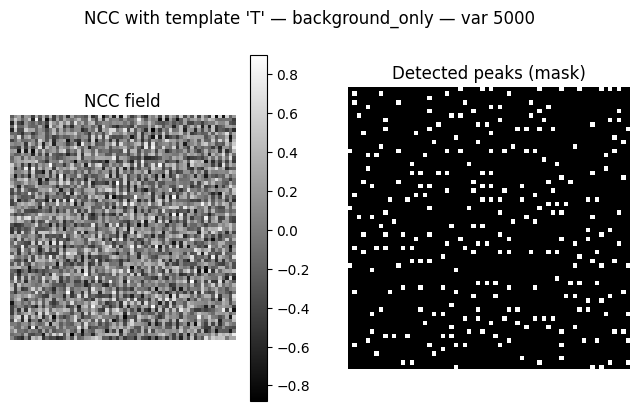

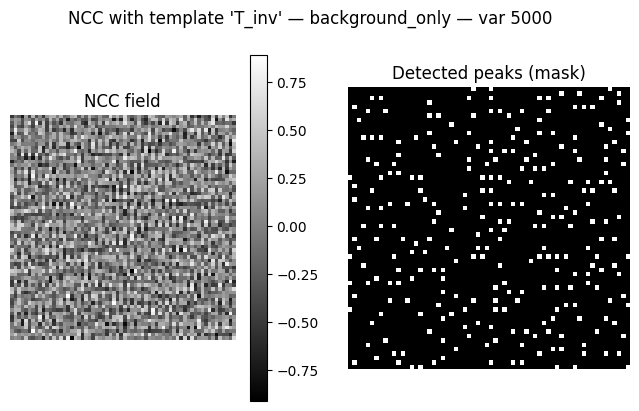

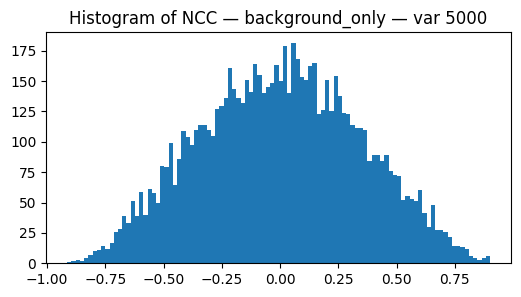

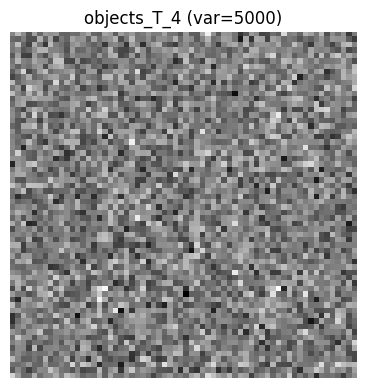

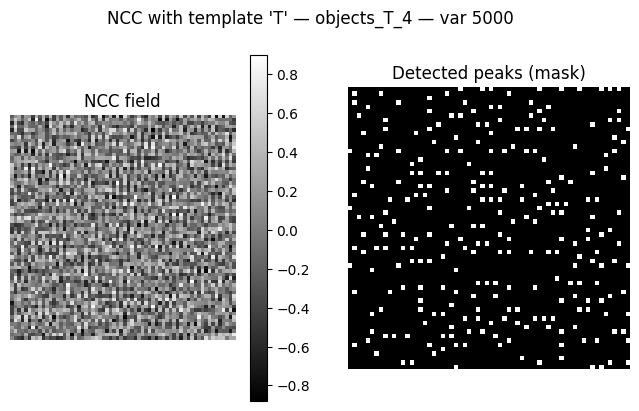

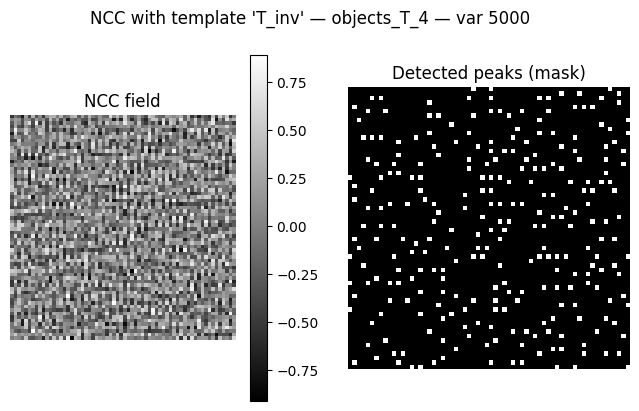

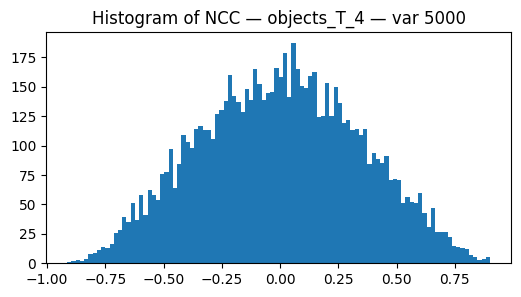

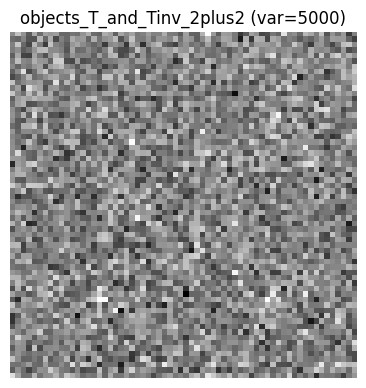

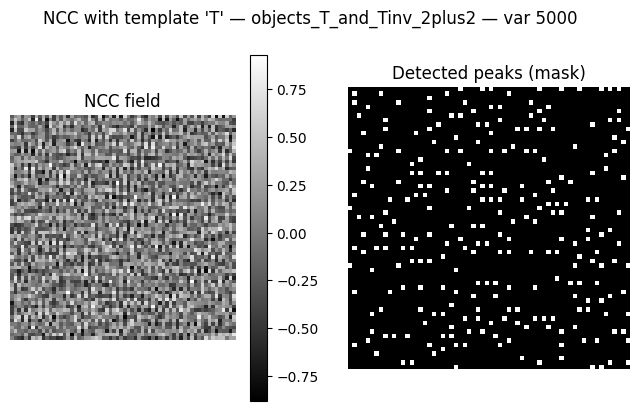

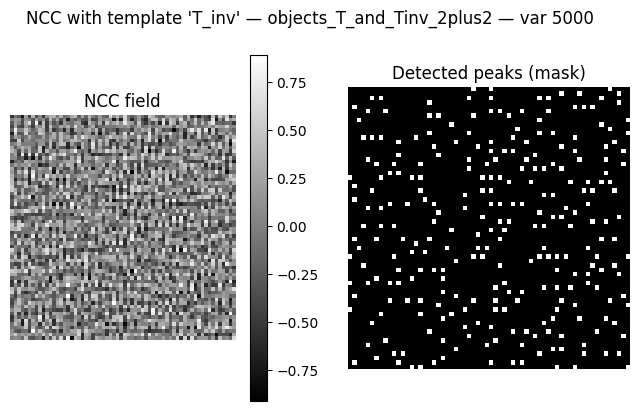

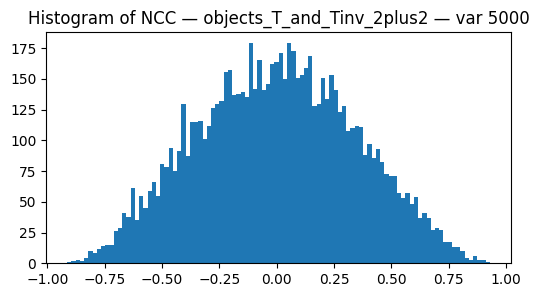


=== Summary for variance = 3000 ===
 Image: background_only
  Template T: matched=0, missed=0, false_pos=278
  Template T_inv: matched=0, missed=0, false_pos=290
 Image: objects_T_4
  Template T: matched=4, missed=0, false_pos=274
  Template T_inv: matched=0, missed=4, false_pos=287
 Image: objects_T_and_Tinv_2plus2
  Template T: matched=2, missed=0, false_pos=275
  Template T_inv: matched=2, missed=0, false_pos=288

=== Summary for variance = 5000 ===
 Image: background_only
  Template T: matched=0, missed=0, false_pos=266
  Template T_inv: matched=0, missed=0, false_pos=269
 Image: objects_T_4
  Template T: matched=3, missed=1, false_pos=263
  Template T_inv: matched=2, missed=2, false_pos=269
 Image: objects_T_and_Tinv_2plus2
  Template T: matched=1, missed=1, false_pos=263
  Template T_inv: matched=2, missed=0, false_pos=270

All outputs saved to './lr4_outputs' (png + .npy).

Threshold sweep (example) for var=3000, image='objects_T_4', template='T':
thr	#dets	matched	missed	false

: 

In [ ]:
results = run_experiment()

# Пример: автоматический подбор порога для одного конкретного случая:
# (берём variance=3000, изображение objects_T_4, template T)
var = VAR_LIST[0]
img = results[var]["objects_T_4"]["image"]
true_centers = CENTERS_4T
thresholds = np.linspace(0.1, 0.9, 17)
ncc_field, sweep = threshold_sweep_for_image(img, T, thresholds, true_centers)

# печатаем таблицу подбора порога
print("\nThreshold sweep (example) for var={}, image='objects_T_4', template='T':".format(var))
print("thr\t#dets\tmatched\tmissed\tfalse_pos")
for thr in thresholds:
    v = sweep[thr]
    print(f"{thr:.2f}\t{v['num_dets']}\t{v['matched']}\t{v['missed']}\t{v['fp']}")

# сохраняем sweep в файл
import json
sweep_path = os.path.join(OUTDIR, f"threshold_sweep_var{var}_objects_T_4_T.json")
with open(sweep_path, "w") as f:
    json.dump({str(k): v for k,v in sweep.items()}, f, indent=2)
print(f"\nSaved threshold sweep to {sweep_path}")